In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

SEED = 42

tf.keras.utils.set_random_seed(SEED)

# Ask TensorFlow to use deterministic operations where available.
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [3]:
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train_raw.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test_raw.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [4]:
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# MNIST images are grayscale, so the channel dimension is 1.
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Processed training images:", x_train.shape)
print("Processed test images:", x_test.shape)

Processed training images: (60000, 28, 28, 1)
Processed test images: (10000, 28, 28, 1)


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9281 - loss: 0.2492 - val_accuracy: 0.9812 - val_loss: 0.0639
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9791 - loss: 0.0672 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9875 - val_loss: 0.0404
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9895 - val_loss: 0.0361


In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

Test loss:     0.0333
Test accuracy: 98.9300%


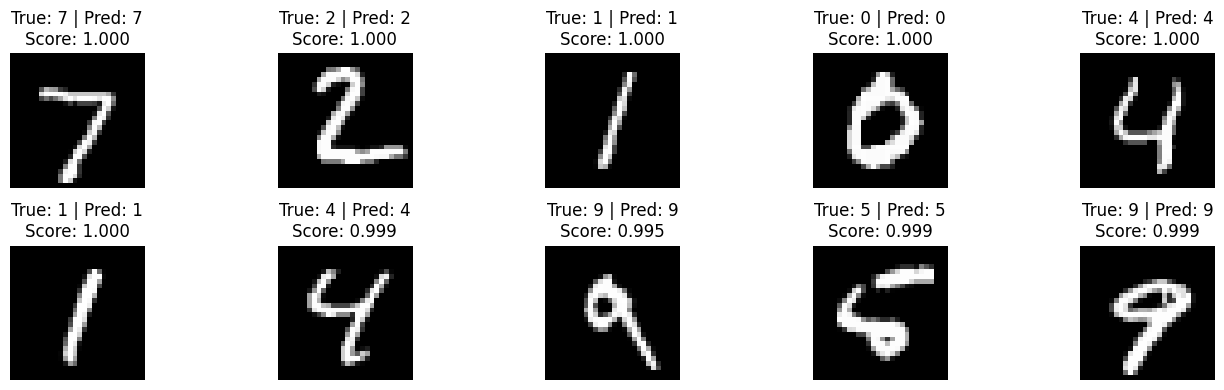

In [8]:
sample_count = 10
sample_images = x_test[:sample_count]
sample_labels = y_test[:sample_count]

probabilities = model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
top_scores = np.max(probabilities, axis=1)

plt.figure(figsize=(14, 4))

for i in range(sample_count):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {sample_labels[i]} | Pred: {predicted_labels[i]}\n"
        f"Score: {top_scores[i]:.3f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# Day 3- Checking Model Confidence- Temperature Scaling

**Take the trained model, stop it just before the final softmax, and get the raw scores so we can calibrate the model's confidence later.**

In [10]:

validation_size = int(len(x_train) * 0.1)

x_val = x_train[-validation_size:]
y_val = y_train[-validation_size:]

print("Validation examples:", len(x_val))
print("Test examples:", len(x_test))

Validation examples: 6000
Test examples: 10000


In [14]:
output_layer = model.layers[-1]


inputs = tf.keras.Input(shape=(28, 28, 1))
features = inputs

for layer in model.layers[:-1]:
    features = layer(features)

feature_model = tf.keras.Model(inputs=inputs, outputs=features)

val_features = feature_model.predict(x_val, batch_size=256, verbose=0)
test_features = feature_model.predict(x_test, batch_size=256, verbose=0)

val_logits = val_features @ output_layer.kernel.numpy()
test_logits = test_features @ output_layer.kernel.numpy()

if output_layer.use_bias:
    val_logits += output_layer.bias.numpy()
    test_logits += output_layer.bias.numpy()

print("Validation logits:", val_logits.shape)
print("Test logits:", test_logits.shape)

Validation logits: (6000, 10)
Test logits: (10000, 10)


**This cell creates functions to calculate prediction confidence, correctness, and calibration error.**

In [15]:
def probabilities_from_logits(logits, temperature=1.0):
    """Divide logits by temperature and convert them to probabilities."""
    return tf.nn.softmax(logits / temperature, axis=1).numpy()


def confidence_and_correctness(probabilities, labels):
    predictions = np.argmax(probabilities, axis=1)
    confidence = np.max(probabilities, axis=1)
    correct = predictions == labels
    return confidence, correct


def expected_calibration_error(probabilities, labels, num_bins=15):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    ece = 0.0

    for bin_index in range(num_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == num_bins - 1:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence >= lower) & (confidence < upper)

        if np.any(in_bin):
            bin_accuracy = np.mean(correct[in_bin])
            bin_confidence = np.mean(confidence[in_bin])
            ece += np.mean(in_bin) * abs(bin_accuracy - bin_confidence)

    return float(ece)


def summarize_mnist(probabilities, labels):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    return {
        "accuracy": float(np.mean(correct)),
        "average_confidence": float(np.mean(confidence)),
        "ece": expected_calibration_error(probabilities, labels),
    }

**This cell calculates the model's original probabilities and measures its accuracy, confidence, and calibration error before calibration.**

In [16]:
val_raw_probabilities = probabilities_from_logits(val_logits)
test_raw_probabilities = probabilities_from_logits(test_logits)

val_raw_metrics = summarize_mnist(val_raw_probabilities, y_val)
test_raw_metrics = summarize_mnist(test_raw_probabilities, y_test)

print("Raw validation:", val_raw_metrics)
print("Raw test:", test_raw_metrics)

Raw validation: {'accuracy': 0.9895, 'average_confidence': 0.9914257526397705, 'ece': 0.002157481660445489}
Raw test: {'accuracy': 0.9893, 'average_confidence': 0.9902321100234985, 'ece': 0.002270258209109267}


**This cell finds the best temperature value using the validation data. The temperature will be used to adjust the model's confidence.**

In [17]:
log_temperature = tf.Variable(0.0, dtype=tf.float32)
temperature_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

val_logits_tensor = tf.convert_to_tensor(val_logits, dtype=tf.float32)
y_val_tensor = tf.convert_to_tensor(y_val, dtype=tf.int32)

for step in range(200):
    with tf.GradientTape() as tape:
        temperature = tf.exp(log_temperature)
        scaled_val_logits = val_logits_tensor / temperature
        val_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                y_val_tensor,
                scaled_val_logits,
                from_logits=True,
            )
        )

    gradient = tape.gradient(val_loss, [log_temperature])
    temperature_optimizer.apply_gradients(
        zip(gradient, [log_temperature])
    )

learned_temperature = float(tf.exp(log_temperature).numpy())
print(f"Learned temperature: {learned_temperature:.4f}")

Learned temperature: 1.1658


**This cell applies the learned temperature to the model's predictions and compares the results before and after calibration.**

In [19]:
import pandas as pd
val_calibrated_probabilities = probabilities_from_logits(
    val_logits, learned_temperature
)
test_calibrated_probabilities = probabilities_from_logits(
    test_logits, learned_temperature
)

val_calibrated_metrics = summarize_mnist(
    val_calibrated_probabilities, y_val
)
test_calibrated_metrics = summarize_mnist(
    test_calibrated_probabilities, y_test
)

mnist_results = pd.DataFrame([
    {"split": "Validation", "version": "Raw", **val_raw_metrics},
    {"split": "Validation", "version": "Calibrated", **val_calibrated_metrics},
    {"split": "Test", "version": "Raw", **test_raw_metrics},
    {"split": "Test", "version": "Calibrated", **test_calibrated_metrics},
])

display(mnist_results.style.format({
    "accuracy": "{:.4f}",
    "average_confidence": "{:.4f}",
    "ece": "{:.4f}",
}))

,split,version,accuracy,average_confidence,ece
0,Validation,Raw,0.9895,0.9914,0.0022
1,Validation,Calibrated,0.9895,0.9890,0.0019
2,Test,Raw,0.9893,0.9902,0.0023
3,Test,Calibrated,0.9893,0.9875,0.0025


**This cell creates graphs to compare the model's confidence before and after calibration.**

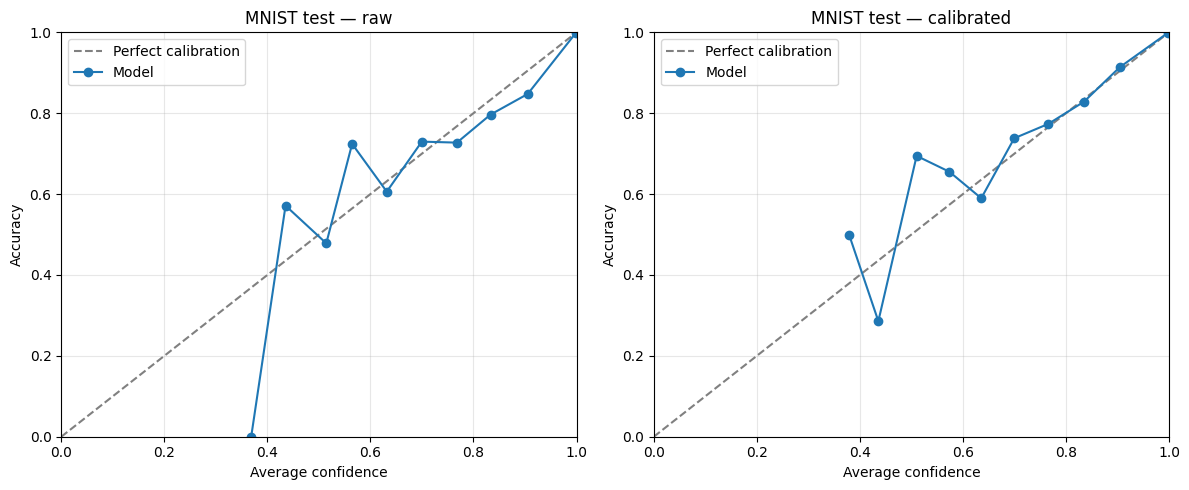

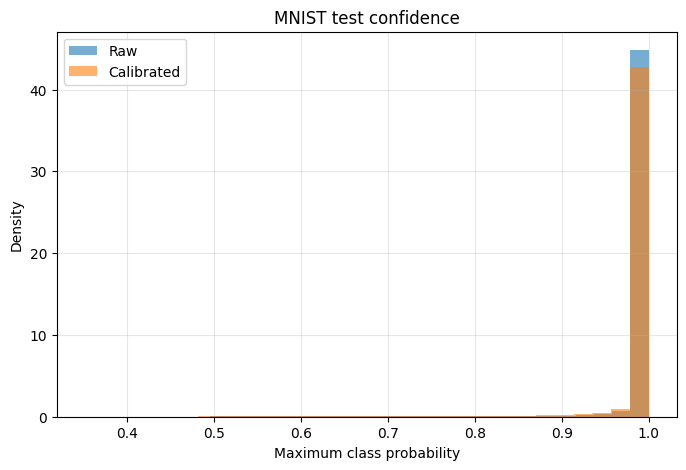

In [20]:
def plot_reliability_diagram(probabilities, labels, title, num_bins=15):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    bin_confidences = []
    bin_accuracies = []

    for bin_index in range(num_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == num_bins - 1:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence >= lower) & (confidence < upper)

        if np.any(in_bin):
            bin_confidences.append(np.mean(confidence[in_bin]))
            bin_accuracies.append(np.mean(correct[in_bin]))

    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.plot(bin_confidences, bin_accuracies, "o-", label="Model")
    plt.xlabel("Average confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0])
plot_reliability_diagram(
    test_raw_probabilities, y_test, "MNIST test — raw"
)

plt.sca(axes[1])
plot_reliability_diagram(
    test_calibrated_probabilities, y_test, "MNIST test — calibrated"
)

plt.tight_layout()
plt.show()

raw_test_confidence = np.max(test_raw_probabilities, axis=1)
calibrated_test_confidence = np.max(test_calibrated_probabilities, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(raw_test_confidence, bins=30, alpha=0.6, label="Raw", density=True)
plt.hist(
    calibrated_test_confidence,
    bins=30,
    alpha=0.6,
    label="Calibrated",
    density=True,
)
plt.xlabel("Maximum class probability")
plt.ylabel("Density")
plt.title("MNIST test confidence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**This cell loads the CIFAR-10 dataset and tests the MNIST model on CIFAR-10 images and compares its confidence before and after calibration.**

In [21]:
(_, _), (x_cifar_raw, _) = tf.keras.datasets.cifar10.load_data()

CIFAR_SUBSET_SIZE = 1000
cifar_rng = np.random.default_rng(SEED)
cifar_indices = cifar_rng.choice(
    len(x_cifar_raw), size=CIFAR_SUBSET_SIZE, replace=False
)
x_cifar_subset = x_cifar_raw[cifar_indices]

cifar_images = tf.convert_to_tensor(x_cifar_subset, dtype=tf.float32) / 255.0
cifar_gray = tf.image.rgb_to_grayscale(cifar_images)
x_cifar = tf.image.resize(cifar_gray, size=(28, 28)).numpy()

cifar_features = feature_model.predict(x_cifar, batch_size=256, verbose=0)
cifar_logits = cifar_features @ output_layer.kernel.numpy()

if output_layer.use_bias:
    cifar_logits += output_layer.bias.numpy()

cifar_raw_probabilities = probabilities_from_logits(cifar_logits)
cifar_calibrated_probabilities = probabilities_from_logits(
    cifar_logits, learned_temperature
)

cifar_raw_confidence = np.max(cifar_raw_probabilities, axis=1)
cifar_calibrated_confidence = np.max(
    cifar_calibrated_probabilities, axis=1
)

confidence_comparison = pd.DataFrame([
    {
        "dataset": "MNIST test",
        "version": "Raw",
        "average_max_probability": float(np.mean(raw_test_confidence)),
        "ece": test_raw_metrics["ece"],
    },
    {
        "dataset": "MNIST test",
        "version": "Calibrated",
        "average_max_probability": float(np.mean(calibrated_test_confidence)),
        "ece": test_calibrated_metrics["ece"],
    },
    {
        "dataset": "CIFAR-10 subset (descriptive only)",
        "version": "Raw",
        "average_max_probability": float(np.mean(cifar_raw_confidence)),
        "ece": np.nan,
    },
    {
        "dataset": "CIFAR-10 subset (descriptive only)",
        "version": "Calibrated",
        "average_max_probability": float(
            np.mean(cifar_calibrated_confidence)
        ),
        "ece": np.nan,
    },
])

display(confidence_comparison.style.format({
    "average_max_probability": "{:.4f}",
    "ece": "{:.4f}",
}))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2039s 12us/step


,dataset,version,average_max_probability,ece
0,MNIST test,Raw,0.9902,0.0023
1,MNIST test,Calibrated,0.9875,0.0025
2,CIFAR-10 subset (descriptive only),Raw,0.4931,nan
3,CIFAR-10 subset (descriptive only),Calibrated,0.4465,nan


**This cell displays some MNIST and CIFAR-10 images with their predicted labels and confidence scores before and after calibration.**

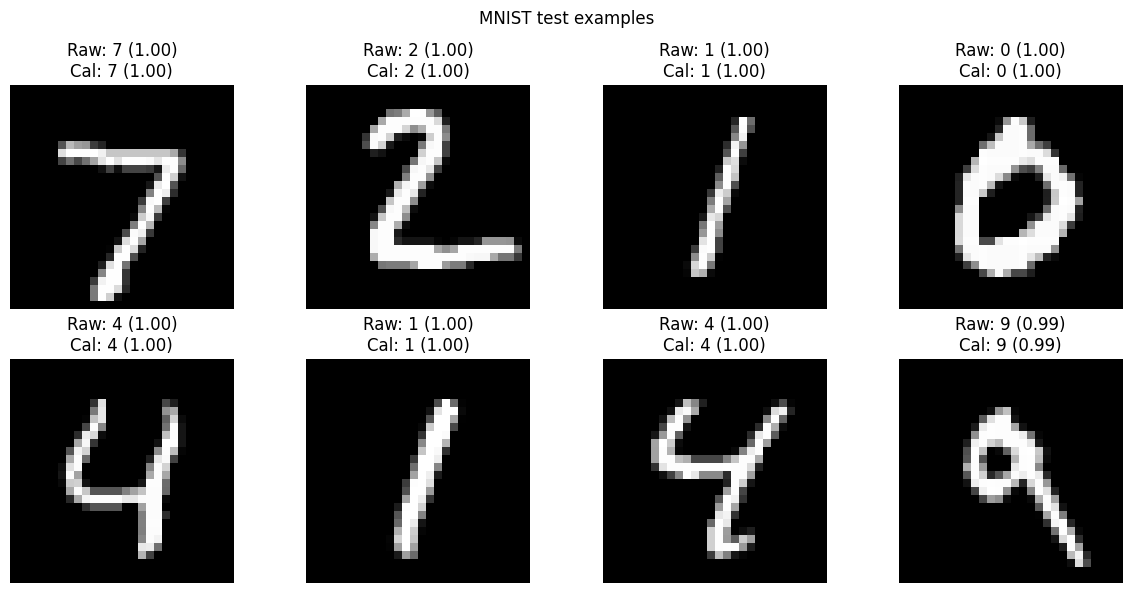

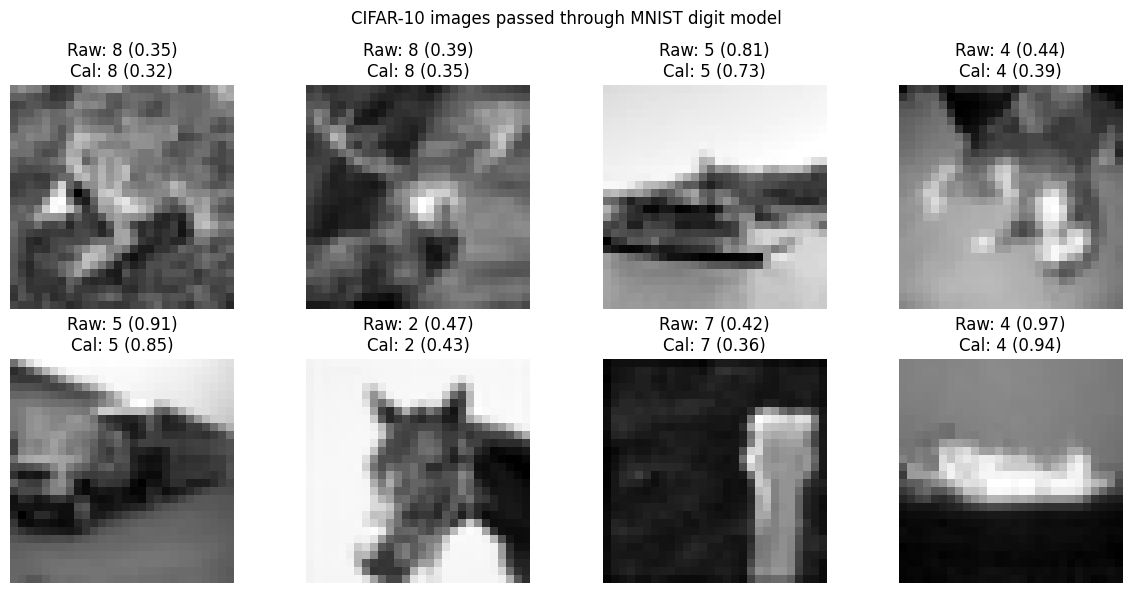

In [22]:
def show_examples(images, raw_probabilities, calibrated_probabilities,
                  title, count=8):
    count = min(count, len(images))
    columns = 4
    rows = int(np.ceil(count / columns))

    plt.figure(figsize=(12, 3 * rows))

    for i in range(count):
        raw_prediction = int(np.argmax(raw_probabilities[i]))
        calibrated_prediction = int(np.argmax(calibrated_probabilities[i]))
        raw_conf = float(np.max(raw_probabilities[i]))
        calibrated_conf = float(np.max(calibrated_probabilities[i]))

        plt.subplot(rows, columns, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(
            f"Raw: {raw_prediction} ({raw_conf:.2f})\n"
            f"Cal: {calibrated_prediction} ({calibrated_conf:.2f})"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(
    x_test,
    test_raw_probabilities,
    test_calibrated_probabilities,
    "MNIST test examples",
)

show_examples(
    x_cifar,
    cifar_raw_probabilities,
    cifar_calibrated_probabilities,
    "CIFAR-10 images passed through MNIST digit model",
)

**This cell prints the final results, including accuracy, confidence, calibration error, and the effect of temperature calibration.**

In [23]:
print(f"Temperature fitted on MNIST validation only: {learned_temperature:.4f}")
print(
    f"MNIST test accuracy — raw: {test_raw_metrics['accuracy']:.4f}; "
    f"calibrated: {test_calibrated_metrics['accuracy']:.4f}"
)
print(
    f"MNIST test ECE — raw: {test_raw_metrics['ece']:.4f}; "
    f"calibrated: {test_calibrated_metrics['ece']:.4f}"
)
print(
    "MNIST test average confidence — "
    f"raw: {test_raw_metrics['average_confidence']:.4f}; "
    f"calibrated: {test_calibrated_metrics['average_confidence']:.4f}"
)
print(
    "CIFAR-10 subset average confidence — "
    f"raw: {np.mean(cifar_raw_confidence):.4f}; "
    f"calibrated: {np.mean(cifar_calibrated_confidence):.4f}"
)

if test_calibrated_metrics["ece"] < test_raw_metrics["ece"]:
    print("On this run, calibrated MNIST test ECE is lower.")
elif test_calibrated_metrics["ece"] > test_raw_metrics["ece"]:
    print("On this run, calibrated MNIST test ECE is higher.")
else:
    print("On this run, MNIST test ECE is unchanged.")

print(
    "CIFAR-10 results describe confidence only; they are not CIFAR-10 "
    "accuracy or ECE."
)

Temperature fitted on MNIST validation only: 1.1658
MNIST test accuracy — raw: 0.9893; calibrated: 0.9893
MNIST test ECE — raw: 0.0023; calibrated: 0.0025
MNIST test average confidence — raw: 0.9902; calibrated: 0.9875
CIFAR-10 subset average confidence — raw: 0.4931; calibrated: 0.4465
On this run, calibrated MNIST test ECE is higher.
CIFAR-10 results describe confidence only; they are not CIFAR-10 accuracy or ECE.


# Day 4:- Failure Analysis and Logging

**This cell sets the confidence cutoffs from 0.50 to 0.95. It also defines a reusable function that calculates how many examples would be answered, how many would be rejected, and the accuracy among answered MNIST examples.**

In [24]:
thresholds = np.round(np.arange(0.50, 0.951, 0.05), 2)


def sweep_confidence_thresholds(confidence, correct=None, thresholds=thresholds):

    confidence = np.asarray(confidence)
    if correct is not None:
        correct = np.asarray(correct, dtype=bool)

    rows = []
    total = len(confidence)

    for threshold in thresholds:
        answered = confidence >= threshold
        answered_count = int(np.sum(answered))
        coverage = answered_count / total if total else np.nan

        if answered_count:
            average_answered_confidence = float(np.mean(confidence[answered]))
        else:
            average_answered_confidence = np.nan

        if correct is None:
            selective_accuracy = "Not applicable"
        elif answered_count:
            selective_accuracy = float(np.mean(correct[answered]))
        else:
            selective_accuracy = np.nan

        rows.append({
            "threshold": float(threshold),
            "total_examples": total,
            "answered_examples": answered_count,
            "coverage": coverage,
            "abstention_rate": 1.0 - coverage,
            "selective_accuracy": selective_accuracy,
            "average_confidence_all": float(np.mean(confidence)),
            "average_confidence_answered": average_answered_confidence,
        })

    return pd.DataFrame(rows)

**This cell checks which MNIST test predictions match the true labels. It then applies the threshold function to raw and calibrated confidence separately.**

In [25]:
mnist_raw_predictions = np.argmax(test_raw_probabilities, axis=1)
mnist_calibrated_predictions = np.argmax(test_calibrated_probabilities, axis=1)

mnist_raw_correct = mnist_raw_predictions == y_test
mnist_calibrated_correct = mnist_calibrated_predictions == y_test

mnist_raw_sweep = sweep_confidence_thresholds(
    raw_test_confidence,
    correct=mnist_raw_correct,
)
mnist_calibrated_sweep = sweep_confidence_thresholds(
    calibrated_test_confidence,
    correct=mnist_calibrated_correct,
)

**This cell applies the same threshold checks to CIFAR-10 confidence. It leaves correctness blank because this model predicts digits, not CIFAR-10 categories.**

In [26]:
cifar_raw_sweep = sweep_confidence_thresholds(
    cifar_raw_confidence,
)
cifar_calibrated_sweep = sweep_confidence_thresholds(
    cifar_calibrated_confidence,
)

**This cell displays the four result tables: MNIST raw, MNIST calibrated, CIFAR-10 raw, and CIFAR-10 calibrated. The formatting just makes the numbers easier to read.**

In [27]:
def display_sweep_table(title, results):
    print(title)
    display(results.style.format({
        "threshold": "{:.2f}",
        "coverage": "{:.3f}",
        "abstention_rate": "{:.3f}",
        "selective_accuracy": lambda value: (
            value if isinstance(value, str) else f"{value:.3f}"
        ),
        "average_confidence_all": "{:.3f}",
        "average_confidence_answered": "{:.3f}",
    }))


display_sweep_table("A. MNIST test — raw confidence", mnist_raw_sweep)
display_sweep_table(
    "B. MNIST test — calibrated confidence",
    mnist_calibrated_sweep,
)
display_sweep_table(
    "C. CIFAR-10 subset — raw confidence",
    cifar_raw_sweep,
)
display_sweep_table(
    "D. CIFAR-10 subset — calibrated confidence",
    cifar_calibrated_sweep,
)

A. MNIST test — raw confidence


,threshold,total_examples,answered_examples,coverage,abstention_rate,selective_accuracy,average_confidence_all,average_confidence_answered
0,0.50,10000,9987,0.999,0.001,0.990,0.990,0.991
1,0.55,10000,9962,0.996,0.004,0.991,0.990,0.992
2,0.60,10000,9940,0.994,0.006,0.992,0.990,0.993
3,0.65,10000,9916,0.992,0.008,0.992,0.990,0.994
4,0.70,10000,9889,0.989,0.011,0.993,0.990,0.995
5,0.75,10000,9859,0.986,0.014,0.994,0.990,0.996
6,0.80,10000,9826,0.983,0.017,0.995,0.990,0.996
7,0.85,10000,9782,0.978,0.022,0.996,0.990,0.997
8,0.90,10000,9727,0.973,0.027,0.997,0.990,0.998
9,0.95,10000,9615,0.962,0.038,0.998,0.990,0.999


B. MNIST test — calibrated confidence


,threshold,total_examples,answered_examples,coverage,abstention_rate,selective_accuracy,average_confidence_all,average_confidence_answered
0,0.50,10000,9981,0.998,0.002,0.991,0.987,0.989
1,0.55,10000,9949,0.995,0.005,0.991,0.987,0.990
2,0.60,10000,9924,0.992,0.008,0.992,0.987,0.991
3,0.65,10000,9896,0.990,0.010,0.993,0.987,0.992
4,0.70,10000,9864,0.986,0.014,0.994,0.987,0.993
5,0.75,10000,9832,0.983,0.017,0.995,0.987,0.994
6,0.80,10000,9790,0.979,0.021,0.996,0.987,0.995
7,0.85,10000,9738,0.974,0.026,0.997,0.987,0.996
8,0.90,10000,9664,0.966,0.034,0.998,0.987,0.997
9,0.95,10000,9501,0.950,0.050,0.999,0.987,0.998


C. CIFAR-10 subset — raw confidence


,threshold,total_examples,answered_examples,coverage,abstention_rate,selective_accuracy,average_confidence_all,average_confidence_answered
0,0.50,1000,420,0.420,0.580,Not applicable,0.493,0.703
1,0.55,1000,349,0.349,0.651,Not applicable,0.493,0.739
2,0.60,1000,301,0.301,0.699,Not applicable,0.493,0.765
3,0.65,1000,234,0.234,0.766,Not applicable,0.493,0.805
4,0.70,1000,201,0.201,0.799,Not applicable,0.493,0.827
5,0.75,1000,156,0.156,0.844,Not applicable,0.493,0.857
6,0.80,1000,113,0.113,0.887,Not applicable,0.493,0.888
7,0.85,1000,70,0.070,0.930,Not applicable,0.493,0.927
8,0.90,1000,48,0.048,0.952,Not applicable,0.493,0.951
9,0.95,1000,27,0.027,0.973,Not applicable,0.493,0.974


D. CIFAR-10 subset — calibrated confidence


,threshold,total_examples,answered_examples,coverage,abstention_rate,selective_accuracy,average_confidence_all,average_confidence_answered
0,0.50,1000,338,0.338,0.662,Not applicable,0.446,0.678
1,0.55,1000,275,0.275,0.725,Not applicable,0.446,0.714
2,0.60,1000,218,0.218,0.782,Not applicable,0.446,0.751
3,0.65,1000,175,0.175,0.825,Not applicable,0.446,0.782
4,0.70,1000,131,0.131,0.869,Not applicable,0.446,0.818
5,0.75,1000,92,0.092,0.908,Not applicable,0.446,0.856
6,0.80,1000,65,0.065,0.935,Not applicable,0.446,0.891
7,0.85,1000,44,0.044,0.956,Not applicable,0.446,0.922
8,0.90,1000,28,0.028,0.972,Not applicable,0.446,0.948
9,0.95,1000,13,0.013,0.987,Not applicable,0.446,0.973


**This graph shows how many images the model would answer at each confidence cutoff. A higher cutoff means the model must be more confident before answering.**

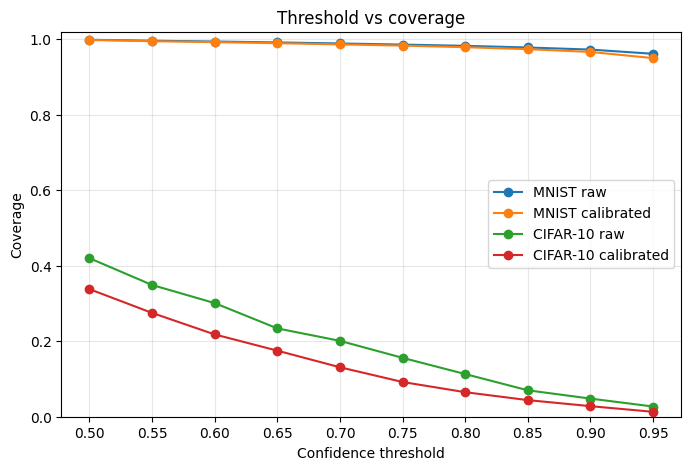

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(
    mnist_raw_sweep["threshold"],
    mnist_raw_sweep["coverage"],
    marker="o",
    label="MNIST raw",
)
plt.plot(
    mnist_calibrated_sweep["threshold"],
    mnist_calibrated_sweep["coverage"],
    marker="o",
    label="MNIST calibrated",
)
plt.plot(
    cifar_raw_sweep["threshold"],
    cifar_raw_sweep["coverage"],
    marker="o",
    label="CIFAR-10 raw",
)
plt.plot(
    cifar_calibrated_sweep["threshold"],
    cifar_calibrated_sweep["coverage"],
    marker="o",
    label="CIFAR-10 calibrated",
)
plt.xlabel("Confidence threshold")
plt.ylabel("Coverage")
plt.title("Threshold vs coverage")
plt.xticks(thresholds)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**This graph shows the share of images the model would reject at each cutoff. Rejection rate is one minus coverage, so it rises as coverage falls.**

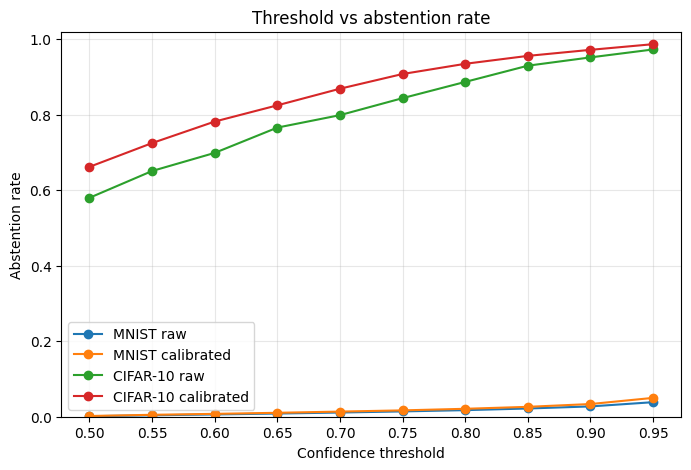

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(
    mnist_raw_sweep["threshold"],
    mnist_raw_sweep["abstention_rate"],
    marker="o",
    label="MNIST raw",
)
plt.plot(
    mnist_calibrated_sweep["threshold"],
    mnist_calibrated_sweep["abstention_rate"],
    marker="o",
    label="MNIST calibrated",
)
plt.plot(
    cifar_raw_sweep["threshold"],
    cifar_raw_sweep["abstention_rate"],
    marker="o",
    label="CIFAR-10 raw",
)
plt.plot(
    cifar_calibrated_sweep["threshold"],
    cifar_calibrated_sweep["abstention_rate"],
    marker="o",
    label="CIFAR-10 calibrated",
)
plt.xlabel("Confidence threshold")
plt.ylabel("Abstention rate")
plt.title("Threshold vs abstention rate")
plt.xticks(thresholds)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**This graph shows accuracy only for MNIST images that pass each cutoff. It compares raw and calibrated confidence.**

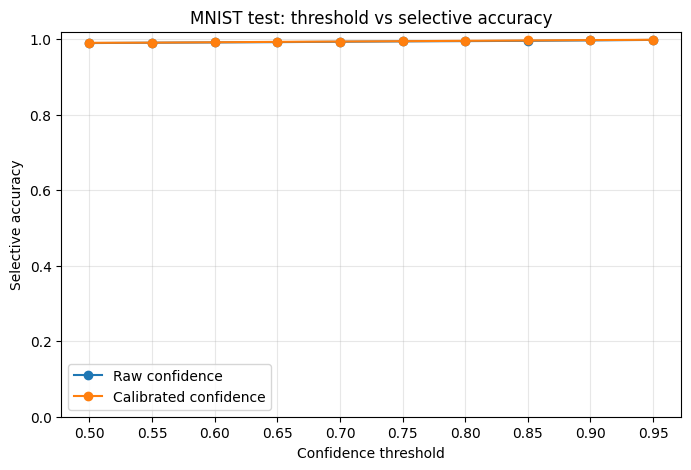

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(
    mnist_raw_sweep["threshold"],
    mnist_raw_sweep["selective_accuracy"],
    marker="o",
    label="Raw confidence",
)
plt.plot(
    mnist_calibrated_sweep["threshold"],
    mnist_calibrated_sweep["selective_accuracy"],
    marker="o",
    label="Calibrated confidence",
)
plt.xlabel("Confidence threshold")
plt.ylabel("Selective accuracy")
plt.title("MNIST test: threshold vs selective accuracy")
plt.xticks(thresholds)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**These graphs show the average confidence among images that pass each cutoff, separately for MNIST and CIFAR-10. The CIFAR-10 values describe confidence only.**

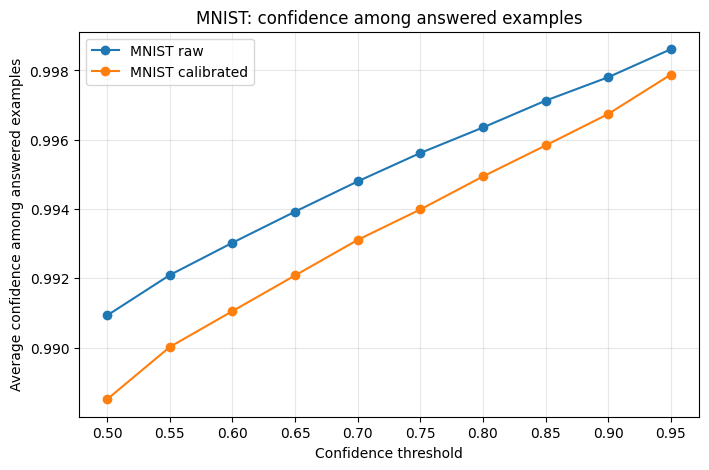

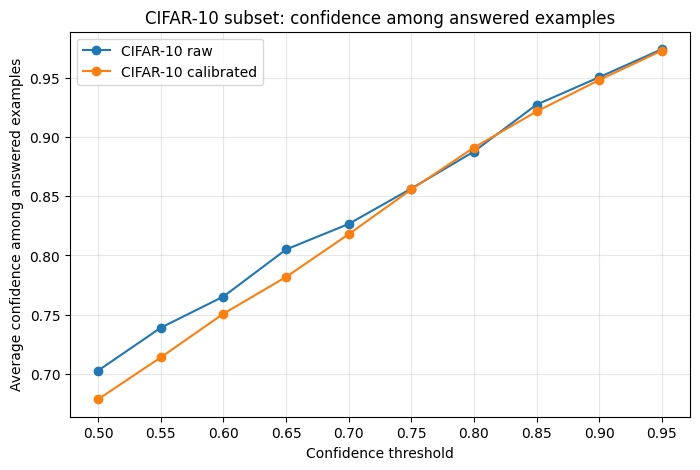

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    mnist_raw_sweep["threshold"],
    mnist_raw_sweep["average_confidence_answered"],
    marker="o",
    label="MNIST raw",
)
plt.plot(
    mnist_calibrated_sweep["threshold"],
    mnist_calibrated_sweep["average_confidence_answered"],
    marker="o",
    label="MNIST calibrated",
)
plt.xlabel("Confidence threshold")
plt.ylabel("Average confidence among answered examples")
plt.title("MNIST: confidence among answered examples")
plt.xticks(thresholds)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    cifar_raw_sweep["threshold"],
    cifar_raw_sweep["average_confidence_answered"],
    marker="o",
    label="CIFAR-10 raw",
)
plt.plot(
    cifar_calibrated_sweep["threshold"],
    cifar_calibrated_sweep["average_confidence_answered"],
    marker="o",
    label="CIFAR-10 calibrated",
)
plt.xlabel("Confidence threshold")
plt.ylabel("Average confidence among answered examples")
plt.title("CIFAR-10 subset: confidence among answered examples")
plt.xticks(thresholds)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**This cell prints the starting and ending results of the sweep and compares raw with calibrated results. It describes the trade-off; it does not choose a cutoff.**

In [32]:
def describe_endpoint_change(results, metric):
    first = results.iloc[0][metric]
    last = results.iloc[-1][metric]
    return float(first), float(last)


for name, results in [
    ("MNIST raw", mnist_raw_sweep),
    ("MNIST calibrated", mnist_calibrated_sweep),
    ("CIFAR-10 raw", cifar_raw_sweep),
    ("CIFAR-10 calibrated", cifar_calibrated_sweep),
]:
    coverage_start, coverage_end = describe_endpoint_change(results, "coverage")
    abstention_start, abstention_end = describe_endpoint_change(
        results, "abstention_rate"
    )

    print(
        f"{name}: coverage changed from {coverage_start:.3f} at "
        f"{thresholds[0]:.2f} to {coverage_end:.3f} at "
        f"{thresholds[-1]:.2f}; abstention changed from "
        f"{abstention_start:.3f} to {abstention_end:.3f}."
    )

for name, results in [
    ("MNIST raw", mnist_raw_sweep),
    ("MNIST calibrated", mnist_calibrated_sweep),
]:
    accuracy_start, accuracy_end = describe_endpoint_change(
        results, "selective_accuracy"
    )
    print(
        f"{name}: selective accuracy among answered examples changed from "
        f"{accuracy_start:.3f} at threshold {thresholds[0]:.2f} to "
        f"{accuracy_end:.3f} at threshold {thresholds[-1]:.2f}."
    )

raw_coverage_gap = np.max(np.abs(
    mnist_raw_sweep["coverage"] - mnist_calibrated_sweep["coverage"]
))
raw_selective_accuracy_gap = np.max(np.abs(
    mnist_raw_sweep["selective_accuracy"]
    - mnist_calibrated_sweep["selective_accuracy"]
))

print(
    "Largest raw-versus-calibrated MNIST coverage difference across "
    f"the sweep: {raw_coverage_gap:.3f}."
)
print(
    "Largest raw-versus-calibrated MNIST selective-accuracy difference "
    f"across the sweep: {raw_selective_accuracy_gap:.3f}."
)

baseline_test_accuracy = float(np.mean(mnist_raw_correct))
high_threshold_accuracy = float(
    mnist_raw_sweep.iloc[-1]["selective_accuracy"]
)
high_threshold_coverage = float(mnist_raw_sweep.iloc[-1]["coverage"])

if high_threshold_coverage > 0 and high_threshold_accuracy > baseline_test_accuracy:
    print(
        "At the strictest tested threshold, answered MNIST examples were "
        "more accurate than the full MNIST test set in this run. This is "
        "evidence of a trade-off on this dataset, not a safety guarantee."
    )
else:
    print(
        "At the strictest tested threshold, the results did not show a "
        "higher selective accuracy than full-set MNIST test accuracy. "
        "Confidence did not demonstrate a clear accuracy benefit at that "
        "point in this run."
    )

print(
    "No single threshold is selected here; this sweep is a diagnostic "
    "comparison only."
)

MNIST raw: coverage changed from 0.999 at 0.50 to 0.962 at 0.95; abstention changed from 0.001 to 0.038.
MNIST calibrated: coverage changed from 0.998 at 0.50 to 0.950 at 0.95; abstention changed from 0.002 to 0.050.
CIFAR-10 raw: coverage changed from 0.420 at 0.50 to 0.027 at 0.95; abstention changed from 0.580 to 0.973.
CIFAR-10 calibrated: coverage changed from 0.338 at 0.50 to 0.013 at 0.95; abstention changed from 0.662 to 0.987.
MNIST raw: selective accuracy among answered examples changed from 0.990 at threshold 0.50 to 0.998 at threshold 0.95.
MNIST calibrated: selective accuracy among answered examples changed from 0.991 at threshold 0.50 to 0.999 at threshold 0.95.
Largest raw-versus-calibrated MNIST coverage difference across the sweep: 0.011.
Largest raw-versus-calibrated MNIST selective-accuracy difference across the sweep: 0.001.
At the strictest tested threshold, answered MNIST examples were more accurate than the full MNIST test set in this run. This is evidence of a t

**This cell finds wrong MNIST predictions with at least 95% confidence. It counts them and displays up to 12 examples with their true label, predicted label, and raw and calibrated confidence.**

,confidence_version,wrong_at_or_above_0.95,percent_of_all_test_images,percent_of_all_mistakes
0,Raw,16,0.160%,14.95%
1,Calibrated,13,0.130%,12.15%


High-confidence mistake cases in the union: 16
Showing up to the top 12, ordered by raw confidence.


,test_index,true_label,predicted_label,raw_confidence,calibrated_confidence,confidence_change
0,4176,2,7,0.9986,0.9960,-0.0026
1,3520,6,4,0.9981,0.9949,-0.0032
2,449,3,5,0.9939,0.9874,-0.0064
3,2921,3,8,0.9934,0.9850,-0.0084
4,4536,6,5,0.9919,0.9828,-0.0091
5,2654,6,1,0.9863,0.9721,-0.0141
6,1226,7,2,0.9861,0.9708,-0.0153
7,2280,3,5,0.9851,0.9675,-0.0176
8,938,3,5,0.9837,0.9708,-0.0129
9,2098,2,0,0.9823,0.9687,-0.0136


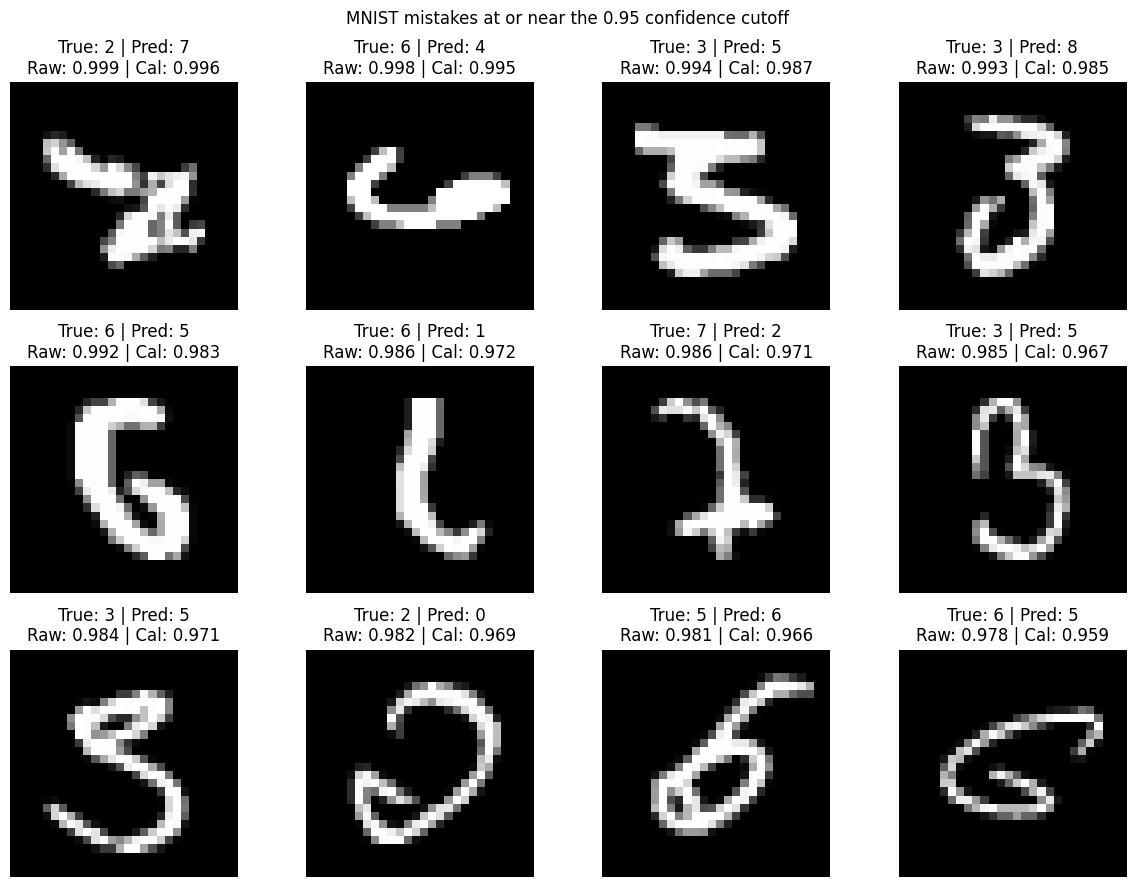

In [33]:
HIGH_CONFIDENCE_THRESHOLD = 0.95
MAX_MNIST_EXAMPLES = 12

mnist_raw_predictions = np.argmax(test_raw_probabilities, axis=1)
mnist_calibrated_predictions = np.argmax(test_calibrated_probabilities, axis=1)

mnist_raw_confidence = np.max(test_raw_probabilities, axis=1)
mnist_calibrated_confidence = np.max(test_calibrated_probabilities, axis=1)


mnist_raw_wrong = mnist_raw_predictions != y_test
mnist_calibrated_wrong = mnist_calibrated_predictions != y_test

raw_high_confidence_mistakes = (
    mnist_raw_wrong & (mnist_raw_confidence >= HIGH_CONFIDENCE_THRESHOLD)
)
calibrated_high_confidence_mistakes = (
    mnist_calibrated_wrong
    & (mnist_calibrated_confidence >= HIGH_CONFIDENCE_THRESHOLD)
)

mnist_failure_union = (
    raw_high_confidence_mistakes | calibrated_high_confidence_mistakes
)
all_mnist_mistakes = mnist_raw_wrong
mistake_count = int(np.sum(all_mnist_mistakes))

mnist_failure_counts = pd.DataFrame([
    {
        "confidence_version": "Raw",
        "wrong_at_or_above_0.95": int(np.sum(raw_high_confidence_mistakes)),
        "percent_of_all_test_images": 100 * np.mean(raw_high_confidence_mistakes),
        "percent_of_all_mistakes": (
            100 * np.sum(raw_high_confidence_mistakes) / mistake_count
            if mistake_count else np.nan
        ),
    },
    {
        "confidence_version": "Calibrated",
        "wrong_at_or_above_0.95": int(np.sum(calibrated_high_confidence_mistakes)),
        "percent_of_all_test_images": 100 * np.mean(calibrated_high_confidence_mistakes),
        "percent_of_all_mistakes": (
            100 * np.sum(calibrated_high_confidence_mistakes) / mistake_count
            if mistake_count else np.nan
        ),
    },
])

display(mnist_failure_counts.style.format({
    "percent_of_all_test_images": "{:.3f}%",
    "percent_of_all_mistakes": "{:.2f}%",
}))

mnist_failure_indices = np.flatnonzero(mnist_failure_union)

if len(mnist_failure_indices) == 0:
    print("No MNIST mistakes met the 0.95 cutoff in either confidence version.")
else:
    mnist_failure_table = pd.DataFrame({
        "test_index": mnist_failure_indices,
        "true_label": y_test[mnist_failure_indices],
        "predicted_label": mnist_raw_predictions[mnist_failure_indices],
        "raw_confidence": mnist_raw_confidence[mnist_failure_indices],
        "calibrated_confidence": mnist_calibrated_confidence[mnist_failure_indices],
    })
    mnist_failure_table["confidence_change"] = (
        mnist_failure_table["calibrated_confidence"]
        - mnist_failure_table["raw_confidence"]
    )
    mnist_failure_table = mnist_failure_table.sort_values(
        "raw_confidence", ascending=False
    ).reset_index(drop=True)

    print(f"High-confidence mistake cases in the union: {len(mnist_failure_table)}")
    print(f"Showing up to the top {MAX_MNIST_EXAMPLES}, ordered by raw confidence.")
    display(mnist_failure_table.head(MAX_MNIST_EXAMPLES).style.format({
        "raw_confidence": "{:.4f}",
        "calibrated_confidence": "{:.4f}",
        "confidence_change": "{:+.4f}",
    }))

    examples_to_show = mnist_failure_table.head(MAX_MNIST_EXAMPLES)
    count_to_show = len(examples_to_show)
    columns = 4
    rows = int(np.ceil(count_to_show / columns))
    plt.figure(figsize=(12, 3 * rows))

    for plot_position, (_, row) in enumerate(examples_to_show.iterrows(), start=1):
        image_index = int(row["test_index"])
        plt.subplot(rows, columns, plot_position)
        plt.imshow(x_test[image_index].squeeze(), cmap="gray")
        plt.title(
            f"True: {int(row['true_label'])} | Pred: {int(row['predicted_label'])}\n"
            f"Raw: {row['raw_confidence']:.3f} | Cal: {row['calibrated_confidence']:.3f}"
        )
        plt.axis("off")

    plt.suptitle("MNIST mistakes at or near the 0.95 confidence cutoff")
    plt.tight_layout()
    plt.show()

**This cell counts CIFAR-10 images above 0.95 raw and calibrated confidence, then finds those above 0.95 in both. It lists and displays up to 12 of those unfamiliar images. Their predicted digits are not checked against CIFAR-10 labels**

,version,images_at_or_above_0.95,percent_of_subset
0,Raw,27,2.70%
1,Calibrated,13,1.30%
2,At or above 0.95 in both,13,1.30%


Showing up to 12 unfamiliar images that remained at or above 0.95 before and after calibration.


,subset_index,predicted_digit,raw_confidence,calibrated_confidence,confidence_change
0,111,2,0.9988,0.9960,-0.0028
1,221,4,0.9983,0.9950,-0.0033
2,791,2,0.9957,0.9887,-0.0070
3,266,2,0.9927,0.9827,-0.0099
4,737,2,0.9926,0.9828,-0.0098
5,222,5,0.9912,0.9789,-0.0123
6,547,4,0.9911,0.9788,-0.0124
7,770,4,0.9862,0.9690,-0.0172
8,476,2,0.9817,0.9610,-0.0206
9,426,5,0.9796,0.9570,-0.0226


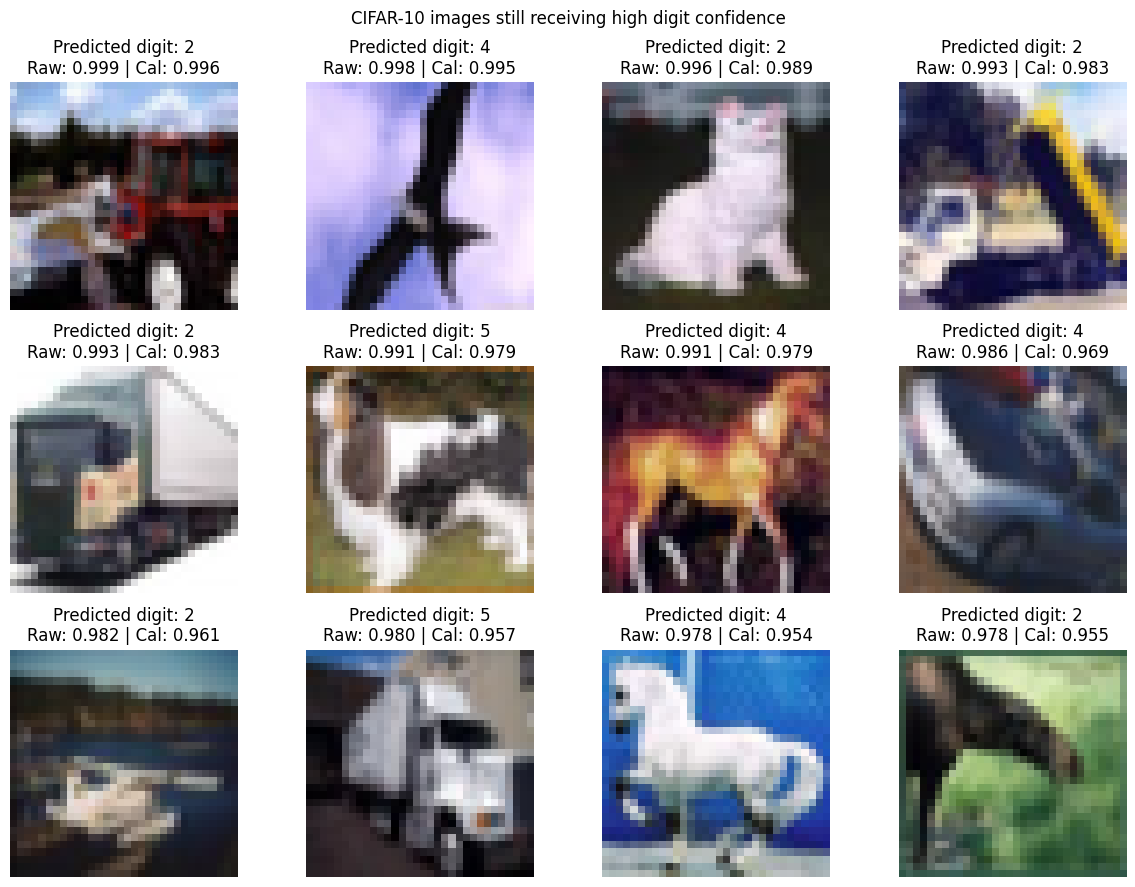

In [34]:
cifar_raw_high = cifar_raw_confidence >= HIGH_CONFIDENCE_THRESHOLD
cifar_calibrated_high = cifar_calibrated_confidence >= HIGH_CONFIDENCE_THRESHOLD
cifar_high_both = cifar_raw_high & cifar_calibrated_high

cifar_high_counts = pd.DataFrame([
    {
        "version": "Raw",
        "images_at_or_above_0.95": int(np.sum(cifar_raw_high)),
        "percent_of_subset": 100 * np.mean(cifar_raw_high),
    },
    {
        "version": "Calibrated",
        "images_at_or_above_0.95": int(np.sum(cifar_calibrated_high)),
        "percent_of_subset": 100 * np.mean(cifar_calibrated_high),
    },
    {
        "version": "At or above 0.95 in both",
        "images_at_or_above_0.95": int(np.sum(cifar_high_both)),
        "percent_of_subset": 100 * np.mean(cifar_high_both),
    },
])

display(cifar_high_counts.style.format({"percent_of_subset": "{:.2f}%"}))

cifar_high_indices = np.flatnonzero(cifar_high_both)
MAX_CIFAR_EXAMPLES = 12

if len(cifar_high_indices) == 0:
    print("No CIFAR-10 subset images were at or above 0.95 in both versions.")
else:
    cifar_high_table = pd.DataFrame({
        "subset_index": cifar_high_indices,
        "predicted_digit": np.argmax(
            cifar_raw_probabilities[cifar_high_indices], axis=1
        ),
        "raw_confidence": cifar_raw_confidence[cifar_high_indices],
        "calibrated_confidence": cifar_calibrated_confidence[cifar_high_indices],
    })
    cifar_high_table["confidence_change"] = (
        cifar_high_table["calibrated_confidence"]
        - cifar_high_table["raw_confidence"]
    )
    cifar_high_table = cifar_high_table.sort_values(
        "raw_confidence", ascending=False
    ).reset_index(drop=True)

    print(
        f"Showing up to {MAX_CIFAR_EXAMPLES} unfamiliar images that remained "
        "at or above 0.95 before and after calibration."
    )
    display(cifar_high_table.head(MAX_CIFAR_EXAMPLES).style.format({
        "raw_confidence": "{:.4f}",
        "calibrated_confidence": "{:.4f}",
        "confidence_change": "{:+.4f}",
    }))

    examples_to_show = cifar_high_table.head(MAX_CIFAR_EXAMPLES)
    count_to_show = len(examples_to_show)
    columns = 4
    rows = int(np.ceil(count_to_show / columns))
    plt.figure(figsize=(12, 3 * rows))

    for plot_position, (_, row) in enumerate(examples_to_show.iterrows(), start=1):
        image_index = int(row["subset_index"])
        plt.subplot(rows, columns, plot_position)
        plt.imshow(x_cifar_subset[image_index])
        plt.title(
            f"Predicted digit: {int(row['predicted_digit'])}\n"
            f"Raw: {row['raw_confidence']:.3f} | Cal: {row['calibrated_confidence']:.3f}"
        )
        plt.axis("off")

    plt.suptitle("CIFAR-10 images still receiving high digit confidence")
    plt.tight_layout()
    plt.show()

**This cell compares raw and calibrated confidence for the selected MNIST mistakes and for the CIFAR-10 subset. It counts cases that stay above 0.95, drop below it, cross upward, or change by less than 0.01.**

In [35]:
def confidence_change_summary(raw_confidence, calibrated_confidence, selected_mask, threshold):
    """Summarize raw-to-calibrated movement for a selected set of cases."""
    selected_mask = np.asarray(selected_mask, dtype=bool)
    raw_selected = raw_confidence[selected_mask]
    calibrated_selected = calibrated_confidence[selected_mask]

    if len(raw_selected) == 0:
        return pd.DataFrame([
            {"case_group": "No selected cases", "count": 0, "percent_of_selected": np.nan}
        ])

    remains_high = (raw_selected >= threshold) & (calibrated_selected >= threshold)
    calibration_drops_below = (raw_selected >= threshold) & (calibrated_selected < threshold)
    calibrated_only_high = (raw_selected < threshold) & (calibrated_selected >= threshold)
    barely_changed = np.abs(calibrated_selected - raw_selected) < 0.01

    groups = [
        ("At/above cutoff in both", remains_high),
        ("Raw high, calibrated below cutoff", calibration_drops_below),
        ("Raw below, calibrated high", calibrated_only_high),
        ("Absolute confidence change < 0.01", barely_changed),
    ]

    return pd.DataFrame([
        {
            "case_group": label,
            "count": int(np.sum(mask)),
            "percent_of_selected": 100 * np.mean(mask),
        }
        for label, mask in groups
    ])


mnist_selected_cases = mnist_failure_union
mnist_calibration_comparison = confidence_change_summary(
    mnist_raw_confidence,
    mnist_calibrated_confidence,
    mnist_selected_cases,
    HIGH_CONFIDENCE_THRESHOLD,
)
print("MNIST: high-confidence mistakes in either version")
display(mnist_calibration_comparison.style.format({
    "percent_of_selected": "{:.2f}%",
}))

cifar_calibration_comparison = confidence_change_summary(
    cifar_raw_confidence,
    cifar_calibrated_confidence,
    np.ones(len(cifar_raw_confidence), dtype=bool),
    HIGH_CONFIDENCE_THRESHOLD,
)
print("CIFAR-10: entire existing subset")
display(cifar_calibration_comparison.style.format({
    "percent_of_selected": "{:.2f}%",
}))

MNIST: high-confidence mistakes in either version


,case_group,count,percent_of_selected
0,At/above cutoff in both,13,81.25%
1,"Raw high, calibrated below cutoff",3,18.75%
2,"Raw below, calibrated high",0,0.00%
3,Absolute confidence change < 0.01,5,31.25%


CIFAR-10: entire existing subset


,case_group,count,percent_of_selected
0,At/above cutoff in both,13,1.30%
1,"Raw high, calibrated below cutoff",14,1.40%
2,"Raw below, calibrated high",0,0.00%
3,Absolute confidence change < 0.01,14,1.40%


**This cell prints a short summary of the high-confidence MNIST mistakes and CIFAR-10 images. It also reminds us that CIFAR-10 predictions here are not checked for correctness.**

In [36]:
raw_mnist_failure_count = int(np.sum(raw_high_confidence_mistakes))
calibrated_mnist_failure_count = int(np.sum(calibrated_high_confidence_mistakes))
raw_cifar_high_count = int(np.sum(cifar_raw_high))
calibrated_cifar_high_count = int(np.sum(cifar_calibrated_high))
cifar_both_high_count = int(np.sum(cifar_high_both))

print("Day 4 — run-specific failure summary")
print(
    f"MNIST wrong predictions at confidence >= {HIGH_CONFIDENCE_THRESHOLD:.2f}: "
    f"{raw_mnist_failure_count} raw and {calibrated_mnist_failure_count} calibrated."
)
print(
    f"CIFAR-10 images at confidence >= {HIGH_CONFIDENCE_THRESHOLD:.2f}: "
    f"{raw_cifar_high_count}/{len(cifar_raw_confidence)} raw "
    f"({100*np.mean(cifar_raw_high):.2f}%) and "
    f"{calibrated_cifar_high_count}/{len(cifar_calibrated_confidence)} calibrated "
    f"({100*np.mean(cifar_calibrated_high):.2f}%)."
)
print(
    f"CIFAR-10 images still >= {HIGH_CONFIDENCE_THRESHOLD:.2f} in both versions: "
    f"{cifar_both_high_count}/{len(cifar_high_both)} "
    f"({100*np.mean(cifar_high_both):.2f}%)."
)

if calibrated_cifar_high_count > 0:
    print(
        "Calibration did not remove every high-confidence CIFAR-10 case; "
        "the remaining outputs are not label-verified errors."
    )
else:
    print("No CIFAR-10 subset images remained above the cutoff after calibration.")

if raw_mnist_failure_count > 0 or calibrated_mnist_failure_count > 0:
    print(
        "At least one MNIST mistake remained above the fixed cutoff in one "
        "confidence version; review the displayed images and table."
    )
else:
    print("No MNIST mistakes met the fixed cutoff in either confidence version.")

print(
    "This experiment shows what happened on these MNIST test examples and "
    "this CIFAR-10 subset only. Confidence alone did not establish whether "
    "every unfamiliar input should be accepted or rejected."
)

Day 4 — run-specific failure summary
MNIST wrong predictions at confidence >= 0.95: 16 raw and 13 calibrated.
CIFAR-10 images at confidence >= 0.95: 27/1000 raw (2.70%) and 13/1000 calibrated (1.30%).
CIFAR-10 images still >= 0.95 in both versions: 13/1000 (1.30%).
Calibration did not remove every high-confidence CIFAR-10 case; the remaining outputs are not label-verified errors.
At least one MNIST mistake remained above the fixed cutoff in one confidence version; review the displayed images and table.
This experiment shows what happened on these MNIST test examples and this CIFAR-10 subset only. Confidence alone did not establish whether every unfamiliar input should be accepted or rejected.


**This cell sets up a log file and a helper that turns one set of probabilities into a prediction, confidence score, and either an answer or an I do not know verdict. Each result is written as a JSON line. The cutoff remains the existing 0.95 value.**

In [37]:
import json
import logging
from pathlib import Path
from uuid import uuid4

LOG_PATH = Path("logs/day4_inference.jsonl")
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

inference_logger = logging.getLogger("confidence_aware_cnn.day4")
inference_logger.setLevel(logging.INFO)
inference_logger.propagate = False
for handler in list(inference_logger.handlers):
    inference_logger.removeHandler(handler)
file_handler = logging.FileHandler(LOG_PATH, encoding="utf-8")
file_handler.setFormatter(logging.Formatter("%(message)s"))
inference_logger.addHandler(file_handler)

def predict_with_abstention(probabilities, dataset, threshold, request_id=None):
    """Turn model probabilities into a prediction/abstain verdict and log it."""
    probabilities = np.asarray(probabilities)
    prediction = int(np.argmax(probabilities))
    confidence = float(np.max(probabilities))
    verdict = "answer" if confidence >= threshold else "I don\'t know"

    record = {
        "request_id": request_id or str(uuid4()),
        "dataset": dataset,
        "prediction": prediction if verdict == "answer" else None,
        "confidence": confidence,
        "threshold": float(threshold),
        "verdict": verdict,
    }
    inference_logger.info(json.dumps(record, sort_keys=True))
    return record

ANALYSIS_THRESHOLD = HIGH_CONFIDENCE_THRESHOLD
print(f"Inference logging enabled: {LOG_PATH}")
print(f"Analysis cutoff: {ANALYSIS_THRESHOLD:.2f} (diagnostic only)")

Inference logging enabled: logs/day4_inference.jsonl
Analysis cutoff: 0.95 (diagnostic only)


**This cell tries the logging helper on one MNIST image, one low-confidence CIFAR-10 image, and one high-confidence CIFAR-10 image. It displays what the helper would answer or reject for each.**

In [38]:

mnist_example_index = 0
cifar_low_candidates = np.flatnonzero(cifar_calibrated_confidence < ANALYSIS_THRESHOLD)
cifar_high_candidates = np.flatnonzero(cifar_calibrated_confidence >= ANALYSIS_THRESHOLD)

assert len(cifar_low_candidates) > 0, "Expected at least one low-confidence CIFAR case."
assert len(cifar_high_candidates) > 0, "Expected at least one high-confidence CIFAR case."

logged_examples = [
    predict_with_abstention(
        test_calibrated_probabilities[mnist_example_index],
        dataset="MNIST",
        threshold=ANALYSIS_THRESHOLD,
        request_id=f"day4-mnist-{mnist_example_index}",
    ),
    predict_with_abstention(
        cifar_calibrated_probabilities[cifar_low_candidates[0]],
        dataset="CIFAR-10",
        threshold=ANALYSIS_THRESHOLD,
        request_id=f"day4-cifar-low-{int(cifar_low_candidates[0])}",
    ),
    predict_with_abstention(
        cifar_calibrated_probabilities[cifar_high_candidates[0]],
        dataset="CIFAR-10",
        threshold=ANALYSIS_THRESHOLD,
        request_id=f"day4-cifar-high-{int(cifar_high_candidates[0])}",
    ),
]

display(pd.DataFrame(logged_examples))

,request_id,dataset,prediction,confidence,threshold,verdict
0,day4-mnist-0,MNIST,7.0,0.999973,0.95,answer
1,day4-cifar-low-0,CIFAR-10,NaN,0.316330,0.95,I don't know
2,day4-cifar-high-111,CIFAR-10,2.0,0.996032,0.95,answer


**This cell reads the recent log entries and checks that each has the expected fields and that the answer/reject decision matches its confidence and cutoff.**

In [39]:
required_fields = {"request_id", "dataset", "prediction", "confidence", "threshold", "verdict"}
log_records = [json.loads(line) for line in LOG_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]

assert log_records, "The inference log should contain at least one record."
for record in log_records[-3:]:
    assert required_fields.issubset(record), f"Missing fields: {required_fields - set(record)}"
    expected_verdict = "answer" if record["confidence"] >= record["threshold"] else "I don\'t know"
    assert record["verdict"] == expected_verdict
    if record["verdict"] == "I don\'t know":
        assert record["prediction"] is None

print(f"Verified {len(log_records[-3:])} recent inference records.")
print("Required fields and verdict logic are valid.")
print("Log path:", LOG_PATH)

Verified 3 recent inference records.
Required fields and verdict logic are valid.
Log path: logs/day4_inference.jsonl
